In [1]:
import json
import requests
from pyjstat import pyjstat
import pandas as pd


with open("skaddeitrafikk.json", "r") as file:
    ssbquery_data = json.load(file)

ssbquery = ssbquery_data["queryObj"]
postUrl  = ssbquery_data["postUrl"]
tabellnummer = ssbquery_data["tableIdForQuery"]

response_ssb = requests.post(postUrl, json=ssbquery)


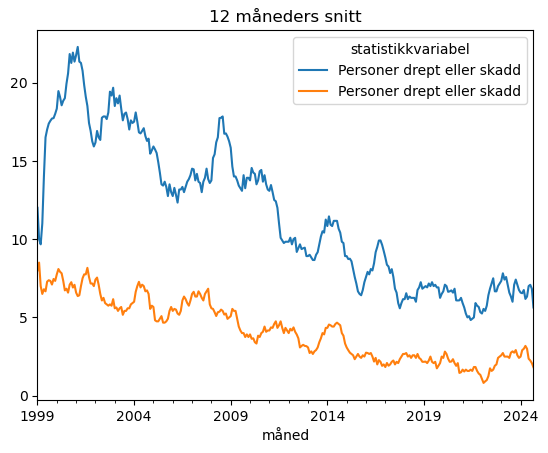

<Axes: xlabel='måned'>

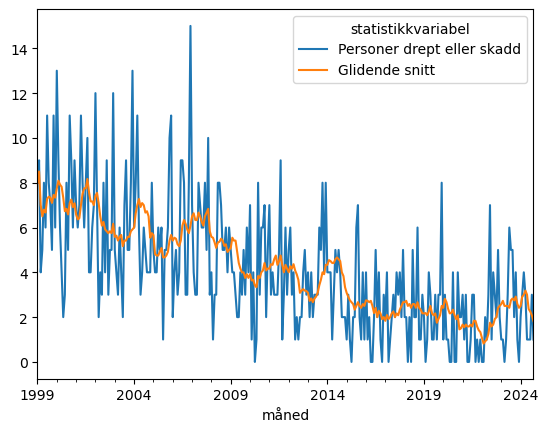

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

dataset = pyjstat.Dataset.read(response_ssb.text)
df = dataset.write("dataframe")
df_id = dataset.write("dataframe", naming="id")

df["måned"] = pd.to_datetime(df["måned"], format="%YM%m")
df=df.pivot(index=["kjønn", "måned"], columns="statistikkvariabel", values="value")

df_kvinner = df.loc["Kvinner"]
df_menn = df.loc["Menn"]
    
verdier = set(df.index.get_level_values(level=0))
verdier

fig, ax = plt.subplots(1,1)
moving_avg = []
for kj in verdier:
    df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4)).mean().plot(ax=ax, label="12mnders snitt")
    moving_avg.append(df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4)).mean())
    #print(list(df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4))["Personer drept eller skadd"]))

moving_avg.reverse()
s = pd.concat(moving_avg)
s.index = df.index
df2 = df.copy()
df2["Glidende snitt"] = s
plt.title("12 måneders snitt")
plt.show()
df2.loc["Kvinner"].plot()

statistikkvariabel,måned,Personer drept eller skadd
statistikkvariabel,,
måned,1.000000,-0.691399
Personer drept eller skadd,-0.691399,1.000000


0.478031993812535


/tmp/ipykernel_57293/266422546.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kvinner["modell"] = model_k.predict(x)


<Axes: xlabel='måned', ylabel='Personer drept eller skadd'>

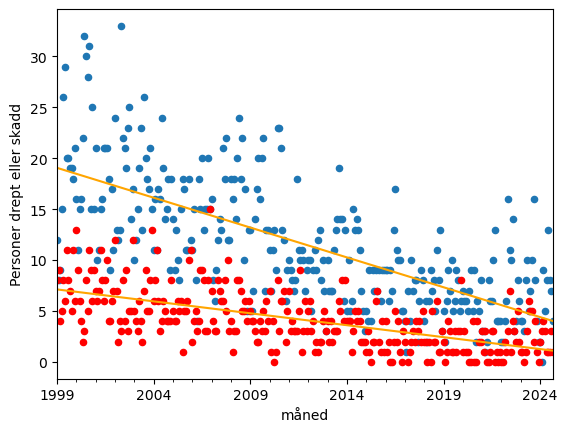

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression

ax = df2.xs("Menn", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd")
display(df.xs("Menn", level=0).reset_index().corr())


df_kvinner = df.xs("Kvinner", level=0)
df_menn = df.loc["Menn"]

x = df_menn.reset_index()[["måned"]]
x["tid"] = x["måned"]-x["måned"].iloc[0]
x["tid"] = x["tid"].dt.days
x = x[["tid"]]

y = df_menn[["Personer drept eller skadd"]]

y_k = df_kvinner[["Personer drept eller skadd"]]

model = LinearRegression()
model_k = LinearRegression()

reg = model.fit(x,y)
reg_k = model_k.fit(x,y_k)
print(reg.score(x,y))

df_menn["modell"] = model.predict(x)
df_menn["modell"].plot(ax=ax, color="orange")
df2.xs("Menn", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd", ax=ax)

df_kvinner["modell"] = model_k.predict(x)
df_kvinner["modell"].plot(ax=ax,color="orange")
df2.xs("Kvinner", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd", ax=ax, color="red")

<Axes: xlabel='måned'>

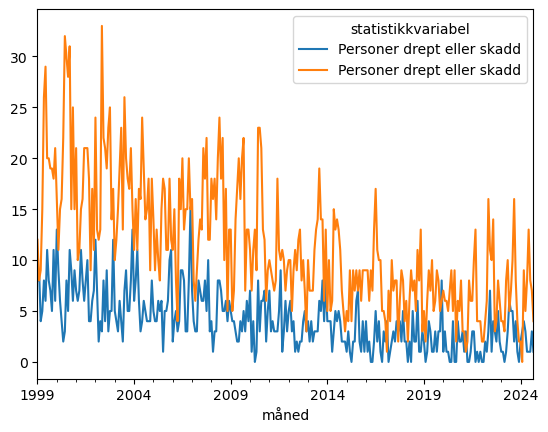

In [7]:
ax = df.loc["Kvinner"].plot()
df.loc["Menn"].plot(ax=ax)

In [8]:
df["tid"] = df[:, "måned"]

statistikkvariabel  Personer drept eller skadd
kjønn   måned                                 
Kvinner 1999-01-01                           8
        1999-02-01                           9
        1999-03-01                           4
        1999-04-01                           5
        1999-05-01                           8
...                                        ...
Menn    2024-05-01                           8
        2024-06-01                          13
        2024-07-01                           8
        2024-08-01                           7
        2024-09-01                           4

[618 rows x 1 columns]